# Práctica 04 : Análisis de datos exploratorio con python y jupiter notebook en un dataset de productos de amazon store

**Programa de estudios:** Ingenieria en Entornos Virtuales y Negocios Digitales \
**Asignatura:** Analítica de datos para negocios digitales \
**Docente:** M.T.I Marco A. Ramírez Hernández \
**Periodo:** Mayo - Agosto 2026

### Unidad 2: Preparación de los datos

**Nombre del Estudiante:** Angelica Citlali Gutierrez Ortega \
**Matricula:** 230426 \
**Grado y Grupo:** 9°A IEVND

<div style="background: linear-gradient(135deg, #FF4081 0%, #880E4F 100%);
padding: 30px;
border-radius: 15px;
text-align: center;">

<h1 style="color: white; font-size: 2.2em; margin: 0; font-family: sans-serif;">
Productos de Amazon Store – Análisis Exploratorio de Datos
Completo & Aprendizaje Automático Predictivo (ML)
</h1>

<p style="color: #FCE4EC; font-size: 1.1em; margin-top: 10px; font-family: sans-serif;">  
Predicción de Precios • Análisis de Categorías •
Ingeniería de Funcionalidades • Comparación de Modelos
</p>

</div>

## Tabla de Contenidos 
| # | Sección | Descripción |
|---|---|---|
| 1 |[Instalaciones & carga de datos](#s1). | Librerias, carga del CVS, primeros comandos de estructura |
| 2 |[Diccionario de datos](#s2) |Explicacion del contenido de columnas y calcular el % de datos faltantes |
| 3 |[Limpieza de datos](#s3) |Aplicacion de metodos basicos de limpieza (elimininacion duplicados,datos nulos) |


## 1. Instalaciones & Carga de Datos <a id='s1'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">

<b>Dataset:</b> Amazon India Listas de Productos – 1,436 productos entre Libros, Kindle, Deportes & más<br>

<b>Objetivo:</b> Predecir el precio del producto (INR) desde la categoría, longitud del nombre, y disponibilidad<br>

<b>DataSource:</b> Web-scraped de páginas de productos Amazon.in

</div>

In [2]:
# =========================================================
# SECTION 1 -Setup & Data Loading
# =========================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
 #ML -Machie Learning -Entrenamiento de modelos matimaticos para predecir en este caso precios 
from sklearn.preprocessing import LabelEncoder,StandardScaler
print(f"✅ NumPy:      {np.__version__}")
print(f"✅ Pandas:     {pd.__version__}")
print('✅ Todas las librerias cargaron con exito')

✅ NumPy:      2.3.5
✅ Pandas:     2.3.3
✅ Todas las librerias cargaron con exito


In [3]:
df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')

print(f"✅ Shape: {df_raw.shape}")
print(f"✅ Columns: {df_raw.columns.tolist()}")

df_raw.head(3)

✅ Shape: (1465, 17)
✅ Columns: ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \r\n Fedor G. Pikus (...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


## 2.- Diccionario de datos del DataFrame.

In [4]:
col_info = {
    'url': 'URL del Producto en Amazon.in',
    'asin': 'Número Estandarizado de Identificación por Amazon (unique ID)',
    'name': 'Nombre o Título del Producto',
    'overview': 'Breve Reseña del Producto (mayoría vacío [])',
    'price': 'Precio como string (e.g. "₹1,600.00")',
    'currency': 'Código de Divisa (todas en INR)',
    'availability': 'Texto del Status del Stock (Inventario)',
    'brand': 'Nombre de la Marca/Autor',
    'about_item': 'Detalles/Especificaciones (mayoría faltante)',
    'img_source': 'URLs de Imágenes del Producto',
    'description': 'Descripción detallada y completa (mayoría faltante)',
    'specifications': 'Especificaciones Técnicas',
    'primary_category': 'Categoría Principal (Libros, Kindle, Deportes...)',
    'category_1': 'Subcategoría de nivel 1',
    'category_2': 'Subcategoría de nivel 2',
    'category_3': 'Subcategoría de nivel 3',
    'breadcrumbs': 'Ruta de categorías',
}

print('Diccionario por columnas:\n')

for col, desc in col_info.items():
    # Validamos si la columna realmente existe en el DataFrame
    if col in df_raw.columns:
        missing_pct = df_raw[col].isnull().mean() * 100
        print(
            f'{col:20s} | '
            f'{desc:45s} | '
            f'missing: {missing_pct:.0f}%'
        )
    else:
        # Si no existe, te lo reporta en lugar de lanzar un error
        print(
            f'{col:20s} | '
            f'{desc:45s} | '
            f'missing: ¡NO ENCONTRADA EN DATAFRAME!'
        )

Diccionario por columnas:

url                  | URL del Producto en Amazon.in                 | missing: ¡NO ENCONTRADA EN DATAFRAME!
asin                 | Número Estandarizado de Identificación por Amazon (unique ID) | missing: 2%
name                 | Nombre o Título del Producto                  | missing: 1%
overview             | Breve Reseña del Producto (mayoría vacío [])  | missing: 2%
price                | Precio como string (e.g. "₹1,600.00")         | missing: 25%
currency             | Código de Divisa (todas en INR)               | missing: 25%
availability         | Texto del Status del Stock (Inventario)       | missing: 34%
brand                | Nombre de la Marca/Autor                      | missing: 2%
about_item           | Detalles/Especificaciones (mayoría faltante)  | missing: 92%
img_source           | URLs de Imágenes del Producto                 | missing: 2%
description          | Descripción detallada y completa (mayoría faltante) | missing: 93%
specifi

## 3. Limpieza de datos

<div style="background:#e6f2ff; padding:12px; border-left:4px solid #0066cc; border-radius:5px; color:#003366;">
<b>Pasos clave para la limpieza:</b><br>
• Parsear los precios de strings como "1,600.00" → float 1600.0<br>
• Manejar los datos faltantes (price: 24%, availability: 33%, description: 92%)<br>
• Estandarizar el texto de disponibilidad en categorías limpias<br>
• Eliminar duplicados
</div>

In [5]:
# ============================================================
# SECTION 2 - Data Cleaning
# ============================================================

df = df_raw.copy()

# ------------------------------------------------------------
# Parse price
# ------------------------------------------------------------
def clean_price(p):
    if pd.isna(p):
        return np.nan

    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)

    return float(m.group()) if m else np.nan


df['price_clean'] = df['price'].apply(clean_price)

# ------------------------------------------------------------
# Standardize availability
# ------------------------------------------------------------
def clean_availability(a):
    if pd.isna(a):
        return 'Unknown'

    a = str(a).strip().lower()

    if 'in stock' in a:
        return 'In Stock'

    if 'unavailable' in a:
        return 'Unavailable'

    if '1 to 3' in a:
        return 'Ships 1-3 weeks'

    if '4 to 5' in a or '6 to' in a or '9 to' in a:
        return 'Ships 4-14 days'

    if '13 to 14' in a or '2 to 3 weeks' in a:
        return 'Ships 2+ weeks'

    if 'only' in a and 'left' in a:
        return 'Low Stock'

    if '2 to 3 days' in a or '1 to 2 days' in a:
        return 'Ships 1-3 days'

    return 'Other'


df['avail_clean'] = df['availability'].apply(clean_availability)

# ------------------------------------------------------------
# Text length features
# ------------------------------------------------------------
df['name_length'] = df['name'].fillna('').str.len()
df['name_words'] = df['name'].fillna('').str.split().str.len()
df['has_brand'] = df['brand'].notna().astype(int)
df['has_desc'] = df['description'].notna().astype(int)
df['has_specs'] = df['specifications'].notna().astype(int)

# ------------------------------------------------------------
# Duplicate check
# ------------------------------------------------------------
dupes = df.duplicated(subset='asin').sum()

print(f'✓ Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'✓ Duplicate ASINs: {dupes}')
print(f'✓ Availability categories: {df["avail_clean"].value_counts().to_dict()}')

df[['name', 'price_clean', 'avail_clean',
    'primary_category', 'name_length']].head(5)

✓ Price parsed: 1,095 / 1,465 products
✓ Duplicate ASINs: 26
✓ Availability categories: {'In Stock': 610, 'Unknown': 500, 'Ships 1-3 weeks': 121, 'Ships 4-14 days': 115, 'Ships 2+ weeks': 80, 'Other': 23, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


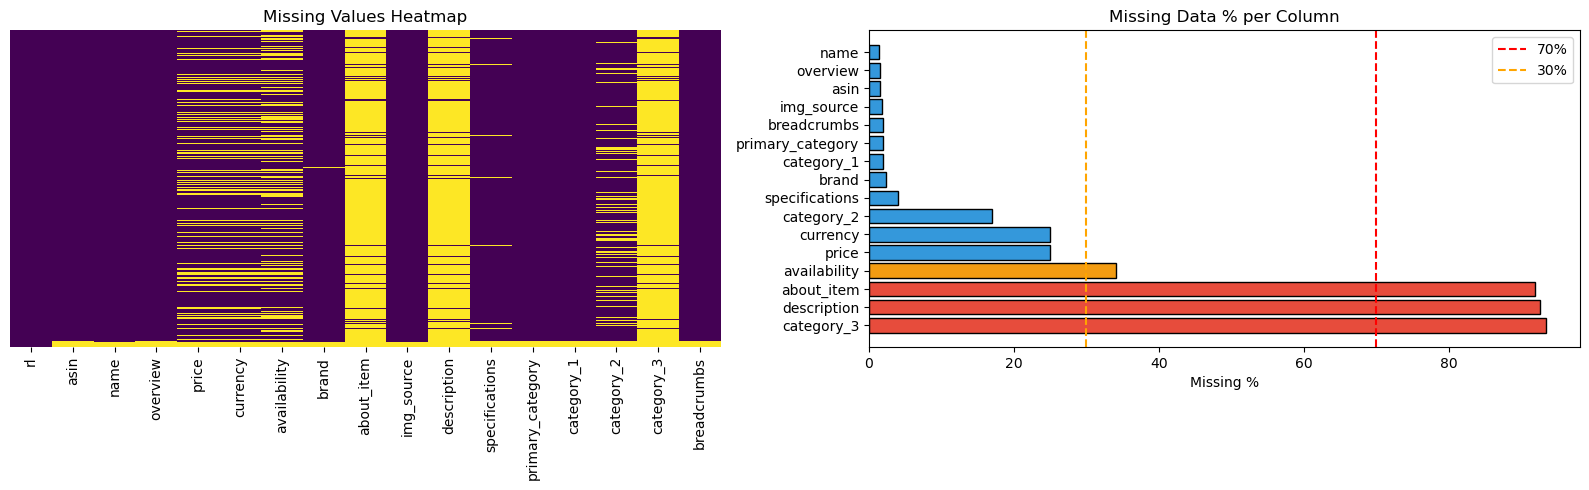

                  Missing Count  Missing Pct
category_3                 1369         93.4
description                1357         92.6
about_item                 1346         91.9
availability                500         34.1
price                       366         25.0
currency                    366         25.0
category_2                  247         16.9
specifications               58          4.0
brand                        33          2.3
category_1                   29          2.0
primary_category             29          2.0
breadcrumbs                  29          2.0
img_source                   26          1.8
asin                         22          1.5
overview                     22          1.5
name                         20          1.4


In [6]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df_raw.isnull().sum(),
    'Missing Pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Aquí corregí 'Viridis' por 'viridis' con minúscula
sns.heatmap(df_raw.isnull(), cbar=False, yticklabels=False,
            cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values Heatmap')

mv = missing[missing['Missing Pct'] > 0]
colors_mv = ['#e74c3c' if v > 70 else '#f39c12' if v > 30 else '#3498db'
             for v in mv['Missing Pct']]

# Dibujar barras solo si hay columnas con valores faltantes
if not mv.empty:
    axes[1].barh(mv.index, mv['Missing Pct'], color=colors_mv, edgecolor='black')
    axes[1].axvline(70, color='red', linestyle='--', label='70%')
    axes[1].axvline(30, color='orange', linestyle='--', label='30%')
    axes[1].set_xlabel('Missing %')
    axes[1].set_title('Missing Data % per Column')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'No hay valores faltantes', 
                 horizontalalignment='center', verticalalignment='center')

plt.tight_layout()
plt.show()

print(missing[missing['Missing Count'] > 0].to_string())

## 4.Ingenieria de caracteristicas (Feature Engineering)

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color:#0066cc;">
<b>Ejemplo Cotidiano:</b> Un agente inmobiliario no solo utiliza los metros cuadrados brutos, sino que también considera la ubicación, la antiguedad y 
el estado. Nosotros hacemos lo mismo: extraemos información más valiosa del texto sin procesar y las categorías.
</div>

In [7]:
# ============================================================
# SECTION 3 — Feature Engineering
# ============================================================

# ── Category flags ───────────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int)
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Sub-category flags ───────────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Availability flags ───────────────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Price features ───────────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Label encode primary category ───────────────────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

# print(f'✅ Total Caracteriscas (Atributos) Procesadas (Features Engineered): {len(df.columns)}')
print('\nPrecio por cada tipo (tier) de distribucion:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)


Precio por cada tipo (tier) de distribucion:
price_tier
1_budget     104
2_low        286
3_mid        320
4_premium    259
5_luxury     126
Unknown      370


,name,price_clean,price_tier,primary_category,is_book,is_instock
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,4_premium,Books,1,0
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,4_premium,Books,1,0
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,0,0
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,0,0
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,4_premium,Books,1,0
5,Valerius Maximus' Memorable Deeds and Sayings ...,NaN,Unknown,Books,1,0


## 5.Análisis Univariante 📊

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color:#0066cc;">
<b>Las gráficas que generamos nos ayudan a visualizar el inventario de los productos de mi dataset y a mostrar qué grupos tienen el mayor volumen de datos. También nos muestran la disponibilidad de los artículos; en palabras simples,<b
nos dicen si hay stock o si se trata de un producto agotado.
    </div>

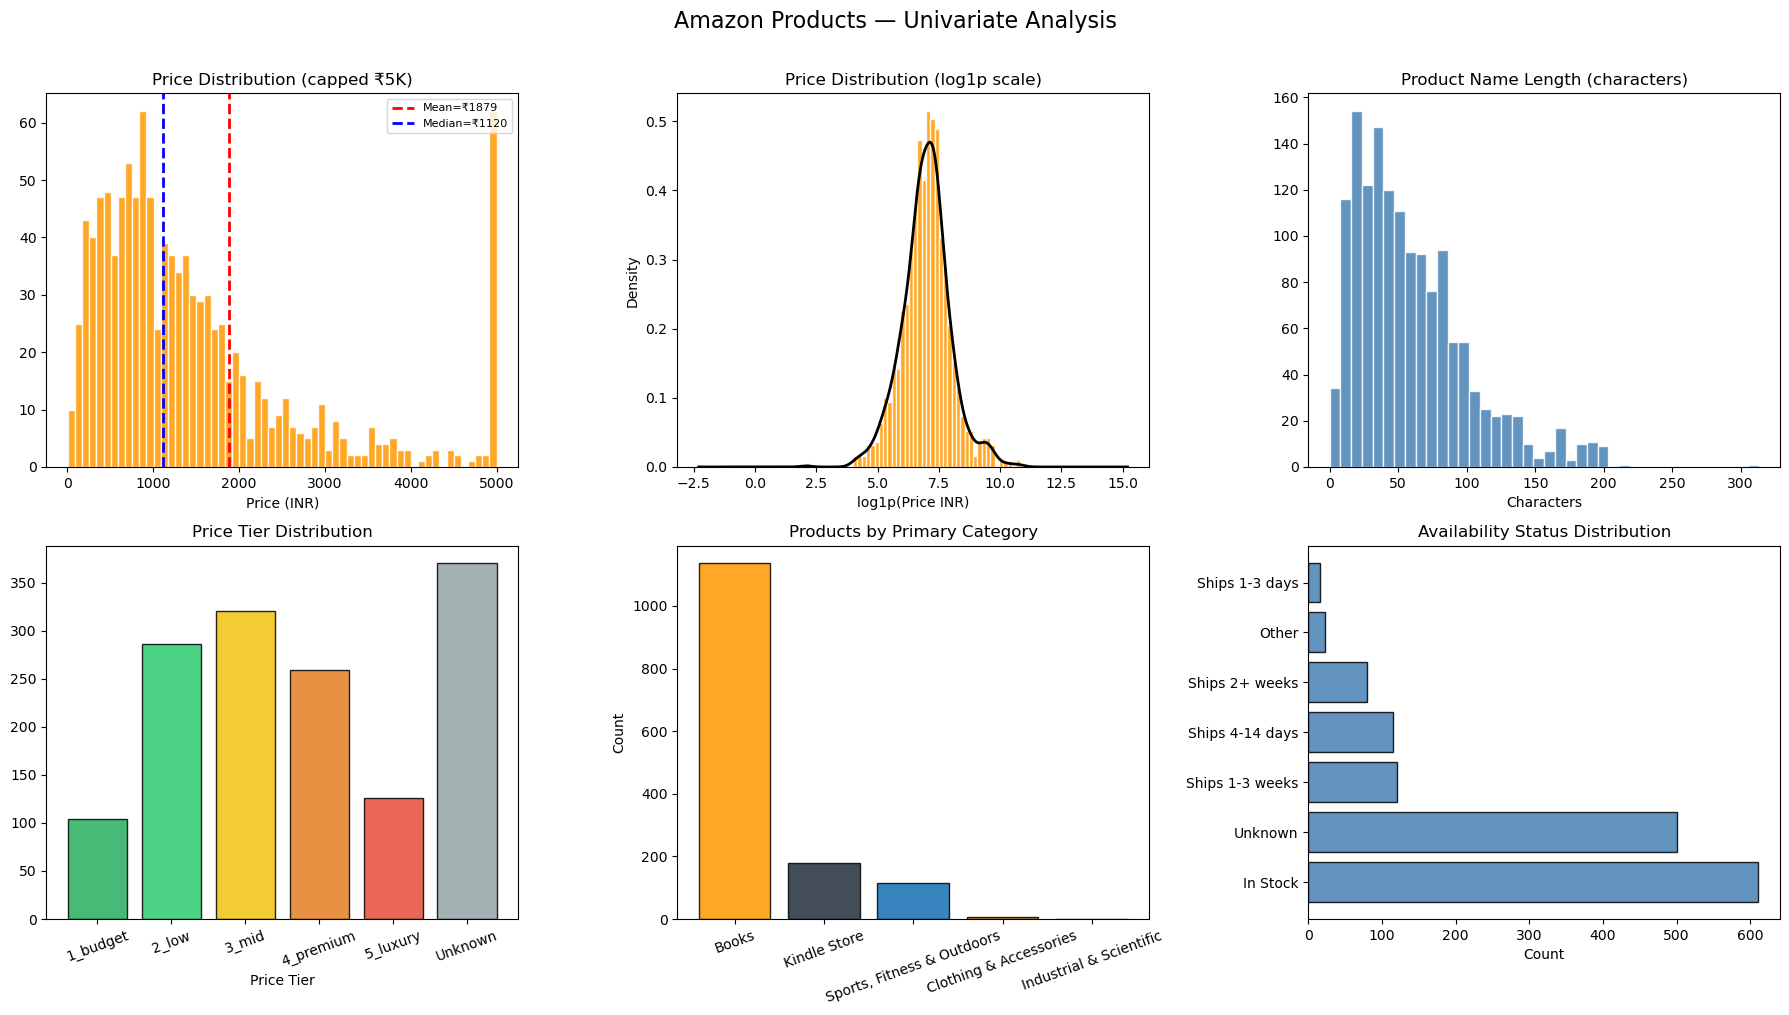

Shapiro-Wilk (log price, n=500): stat=0.9771, p=0.000000
Price is still non-normal after log transform

Price stats (INR):
count     1088.00
mean      1878.65
std       3338.34
min          7.00
25%        611.25
50%       1120.00
75%       1849.25
max      50555.00


In [12]:
# ============================================================
# SECTION 4 — Univariate Analysis
# ============================================================
from scipy.stats import shapiro
df_priced = df[df['price_clean'].notna() & (df['price_clean'] > 0)].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Price raw
axes[0,0].hist(df_priced['price_clean'].clip(upper=5000), bins=60,
               color='#FF9900', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df_priced['price_clean'].mean(), color='red', linestyle='--',
                  lw=2, label=f'Mean=₹{df_priced["price_clean"].mean():.0f}')
axes[0,0].axvline(df_priced['price_clean'].median(), color='blue', linestyle='--',
                  lw=2, label=f'Median=₹{df_priced["price_clean"].median():.0f}')
axes[0,0].set_title('Price Distribution (capped ₹5K)')
axes[0,0].set_xlabel('Price (INR)'); axes[0,0].legend(fontsize=8)

# Price log
axes[0,1].hist(df_priced['log_price'], bins=50, color='#FF9900',
               edgecolor='white', alpha=0.85, density=True)
df_priced['log_price'].plot.kde(ax=axes[0,1], color='black', lw=2)
axes[0,1].set_title('Price Distribution (log1p scale)')
axes[0,1].set_xlabel('log1p(Price INR)')

# Name length
axes[0,2].hist(df['name_length'], bins=40, color='steelblue',
               edgecolor='white', alpha=0.85)
axes[0,2].set_title('Product Name Length (characters)')
axes[0,2].set_xlabel('Characters')

# Price tier
tier_counts = df['price_tier'].value_counts().sort_index()
tier_colors = ['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c','#95a5a6']
axes[1,0].bar(tier_counts.index, tier_counts.values,
              color=tier_colors[:len(tier_counts)], edgecolor='black', alpha=0.85)
axes[1,0].set_title('Price Tier Distribution')
axes[1,0].set_xlabel('Price Tier'); axes[1,0].tick_params(axis='x', rotation=20)

# Primary category
cat_counts = df['primary_category'].value_counts()
axes[1,1].bar(cat_counts.index, cat_counts.values,
              color=['#FF9900','#232F3E','#146EB4','#E47911','#999'],
              edgecolor='black', alpha=0.85)
axes[1,1].set_title('Products by Primary Category')
axes[1,1].set_ylabel('Count'); axes[1,1].tick_params(axis='x', rotation=20)

# Availability
avail_counts = df['avail_clean'].value_counts()
axes[1,2].barh(avail_counts.index, avail_counts.values,
               color='steelblue', edgecolor='black', alpha=0.85)
axes[1,2].set_title('Availability Status Distribution')
axes[1,2].set_xlabel('Count')

plt.suptitle('Amazon Products — Univariate Analysis', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

# Normality test
stat, p = shapiro(df_priced['log_price'].sample(min(500, len(df_priced)), random_state=42))
print(f'Shapiro-Wilk (log price, n=500): stat={stat:.4f}, p={p:.6f}')
print(f'Price is {"normally distributed after log transform" if p > 0.05 else "still non-normal after log transform"}')
print(f'\nPrice stats (INR):')
print(df_priced['price_clean'].describe().round(2).to_string())

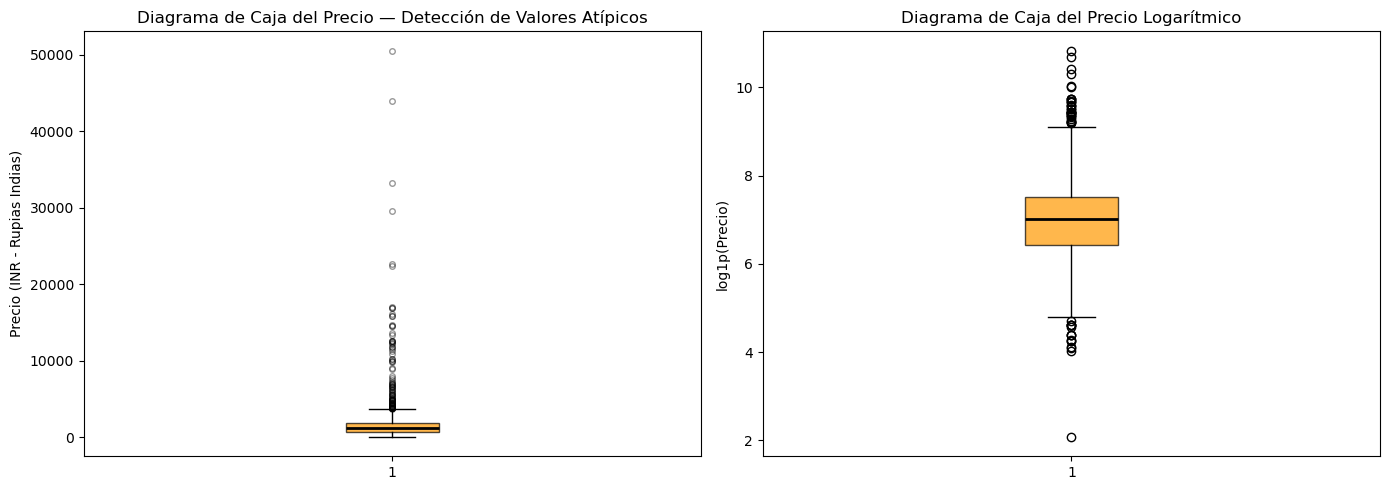

Valores atípicos por método IQR: 93 (8.5%)
Rango de precios (sin valores atípicos): ₹-1246 – ₹3706

Top 10 de productos más caros:
                                                                                                                                        name  price_clean           primary_category
                                            Sprache und Literatur (Literatur der julisch-claudischen und der flavischen Zeit [Schluss]): 032     50555.00                      Books
                                                         Data Mining Algorithms in C++: Data Patterns and Algorithms for Modern Applications     43936.00                      Books
                                                                                Birnbaum's Walt Disney World for Kids 2008 (Birnbaum Guides)     33180.00                      Books
                                                                            Professional Short Films with Autodesk 3ds Max (Graphics Series)     

In [14]:
# ==============================================================================
# ANÁLISIS DE VALORES ATÍPICOS (OUTLIERS) — DIAGRAMA DE CAJA (BOXPLOT) e IQR
# ==============================================================================

# Creamos una figura con 1 fila y 2 columnas para mostrar dos gráficos lado a lado.
# El tamaño asignado de la figura completa es de 14 de ancho por 5 de alto.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Diagrama de Caja del Precio Original ---

# Dibuja un boxplot de los precios limpios en la primera posición [0].
# 'patch_artist=True' permite rellenar la caja con color.
# 'boxprops' define el color naranja de Amazon con un 70% de opacidad.
# 'medianprops' resalta la línea de la mediana en color negro y grosor de 2.
# 'flierprops' configura los puntos que representan los valores atípicos (en color rojo y semi-transparentes).
axes[0].boxplot(df_priced['price_clean'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2),
                flierprops=dict(marker='o', markersize=4, alpha=0.4, color='red'))

# Título y etiquetas en español para el primer gráfico
axes[0].set_title('Diagrama de Caja del Precio — Detección de Valores Atípicos')
axes[0].set_ylabel('Precio (INR - Rupias Indias)')


# --- Gráfico 2: Diagrama de Caja del Precio en Escala Logarítmica ---

# Dibuja un boxplot de la variable transformada 'log_price' en la segunda posición [1].
# Se usan los mismos estilos visuales para mantener consistencia.
axes[1].boxplot(df_priced['log_price'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))

# Título y etiquetas en español para el segundo gráfico
# Al aplicar logaritmo, se reduce la distancia visual que causan los productos caros.
axes[1].set_title('Diagrama de Caja del Precio Logarítmico')
axes[1].set_ylabel('log1p(Precio)')

# Ajusta el espacio para que los títulos y nombres de los ejes no se encimen.
plt.tight_layout()

# Muestra en pantalla el lienzo final con los dos diagramas de caja.
plt.show()


# --- Cálculo Matemático del Rango Intercuartílico (Método IQR) ---

# Calculamos el Primer Cuartil (Q1 - percentil 25) y el Tercer Cuartil (Q3 - percentil 75) del precio.
Q1, Q3 = df_priced['price_clean'].quantile([0.25, 0.75])

# El IQR es la distancia o rango que abarca el 50% de los datos centrales.
IQR = Q3 - Q1

# Identificamos como "outliers" o atípicos a los registros que estén:
# - Por debajo de: Q1 - (1.5 * IQR)
# - Por encima de: Q3 + (1.5 * IQR)
outliers = df_priced[(df_priced['price_clean'] < Q1 - 1.5*IQR) |
                      (df_priced['price_clean'] > Q3 + 1.5*IQR)]

# Imprime la cantidad total de productos atípicos encontrados y el porcentaje que representan en el dataset.
print(f'Valores atípicos por método IQR: {len(outliers)} ({len(outliers)/len(df_priced)*100:.1f}%)')

# Muestra el rango "normal" de precios calculado matemáticamente libre de valores extremos extremos.
print(f'Rango de precios (sin valores atípicos): ₹{Q1-1.5*IQR:.0f} – ₹{Q3+1.5*IQR:.0f}')


# --- Visualización de los Productos de Mayor Valor ---

# Imprime un encabezado para identificar los artículos más caros de la muestra.
print(f'\nTop 10 de productos más caros:')

# Ordena el dataset de mayor a menor según 'price_clean' y extrae las primeras 10 filas.
# Selecciona solo las columnas de 'name' (nombre), 'price_clean' (precio) y 'primary_category' (categoría).
# '.to_string(index=False)' oculta los números de índice de fila para que la tabla se imprima limpia.
print(df_priced.nlargest(10, 'price_clean')[['name','price_clean','primary_category']].to_string(index=False))

## 6.Análisis de Categorías

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color:#0066cc;">
<b>Este análisis nos sirve para ver cuáles pasillos de la tienda acumulan más mercancía y cuáles manejan los precios más altos. Al revisar el volumen de artículos y cruzarlo con sus costos, podemos descubrir en qué partes del negocio se concentra el dinero real. Técnicamente, esto nos permite evaluar cómo se relacionan las variables de tipo texto (las categorías) con los valores numéricos (los precios), ayudándonos a identificar la concentración de los datos y el valor total acumulado antes de entrenar cualquier modelo de predicción. <b>
    </div>

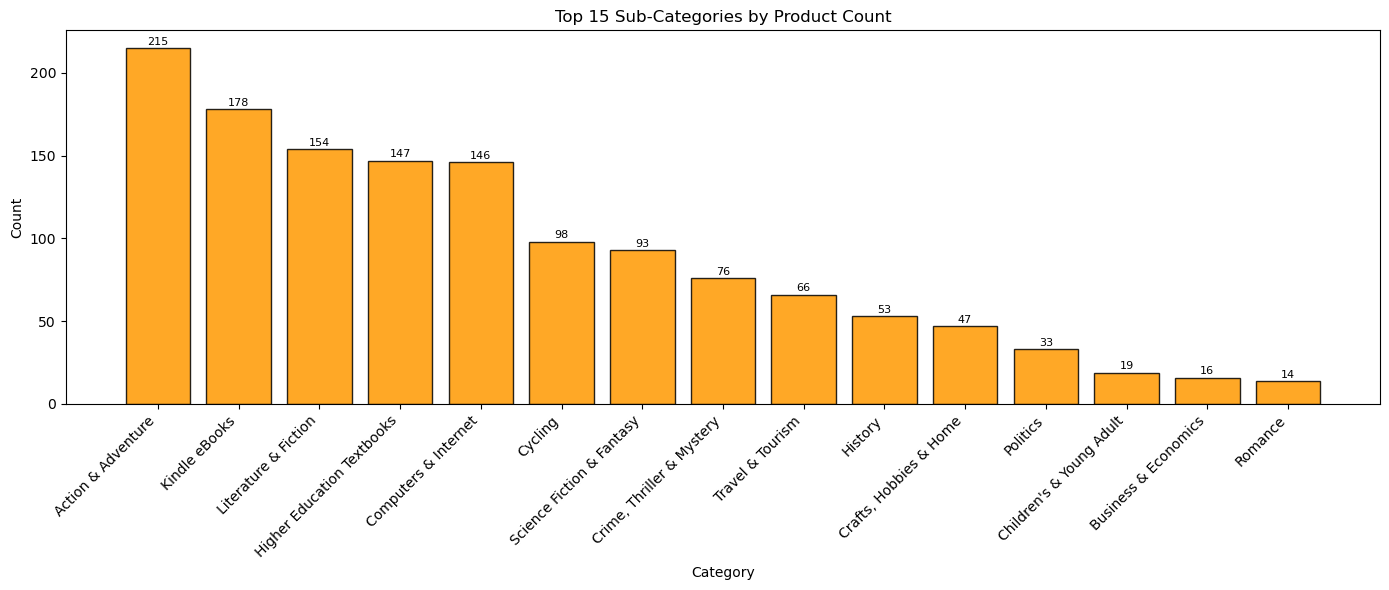

In [15]:
# ==============================================================================
# SECCIÓN 5 — ANÁLISIS DE CATEGORÍAS (CATEGORY ANALYSIS)
# ==============================================================================

# Cuenta cuántos productos pertenecen a cada subcategoría ('category_1').
# Con '.head(15)' seleccionamos únicamente las 15 subcategorías que tienen más productos en el dataset.
top15_cat1 = df['category_1'].value_counts().head(15)

# Crea el lienzo de la gráfica definiendo un tamaño de 14 de ancho por 6 de alto.
plt.figure(figsize=(14, 6))

# Dibuja un gráfico de barras verticales.
# Coloca los nombres de las 15 subcategorías en el eje X y sus cantidades en el eje Y.
# El color elegido es el naranja de Amazon ('#FF9900') con bordes negros y un 85% de opacidad.
bars = plt.bar(top15_cat1.index, top15_cat1.values,
               color='#FF9900', edgecolor='black', alpha=0.85)

# --- Bucle para agregar etiquetas de datos (números sobre las barras) ---
# Recorre cada barra de la gráfica al mismo tiempo que su valor numérico correspondiente.
for bar, val in zip(bars, top15_cat1.values):
    # 'plt.text' coloca un texto en coordenadas específicas:
    # Eje X: El centro exacto de la barra actual (posición inicial X + la mitad de su ancho).
    # Eje Y: Justo arriba de la barra (la altura de la barra + 2 unidades de margen para que no choque).
    # 'str(val)' convierte el número a texto, 'ha='center'' lo alinea al centro y se define un tamaño de letra de 8.
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             str(val), ha='center', fontsize=8)

# Configura el título principal del gráfico y las etiquetas informativas de los ejes X e Y.
plt.title('Top 15 Sub-Categories by Product Count')
plt.xlabel('Category')
plt.ylabel('Count')

# Rota los nombres del eje X 45 grados y los alinea a la derecha ('ha='right'') para evitar que se encimen y sean legibles.
plt.xticks(rotation=45, ha='right')

# Ajusta automáticamente los márgenes de la imagen para que ninguna etiqueta ni texto quede recortado en los bordes.
plt.tight_layout()

# Despliega en pantalla el gráfico final con sus respectivas barras y números.
plt.show()

C:\Users\PC-25\AppData\Local\Temp\ipykernel_6836\1140488297.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(cat_groups, labels=cat_price.index, patch_artist=True,


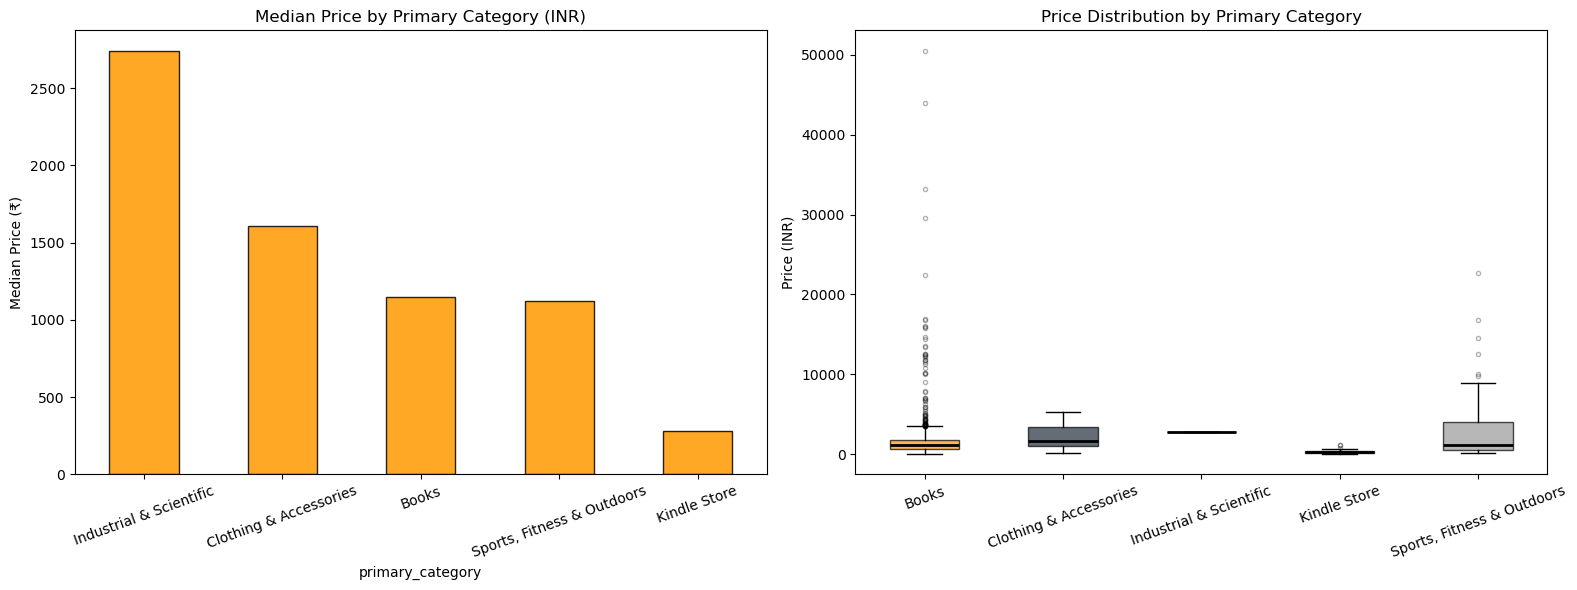

Price stats by primary category:
                              mean  median  count
primary_category                                 
Books                       1825.6  1145.0    955
Clothing & Accessories      2249.2  1606.5      6
Industrial & Scientific     2738.0  2738.0      1
Kindle Store                 350.0   281.4     30
Sports, Fitness & Outdoors  2907.9  1125.0     93


In [16]:
# --- Configuración de los Gráficos ---
# Creamos una figura con 1 fila y 2 columnas para mostrar dos gráficos lado a lado.
# Definimos un tamaño de 16 de ancho por 6 de alto.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Cálculo de Estadísticas por Categoría ---
# Agrupamos los datos por la columna 'primary_category' (Categoría Principal).
# Usamos '.agg()' para calcular al mismo tiempo: el promedio ('mean'), la mediana ('median') y la cantidad de productos ('count').
# Redondeamos los resultados a 1 decimal (.round(1)).
cat_price = df_priced.groupby('primary_category')['price_clean'].agg(['mean','median','count']).round(1)

# --- Gráfico 1: Barras de la Mediana de Precios ---
# Tomamos la columna de medianas, la ordenamos de mayor a menor y la graficamos en formato de barras (.plot.bar).
# 'ax=axes[0]' le indica a Python que este gráfico va en la primera posición (izquierda).
# Usamos el color naranja de Amazon, bordes negros y una opacidad del 85%.
cat_price['median'].sort_values(ascending=False).plot.bar(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)

# Agregamos el título y la etiqueta del eje Y en el primer gráfico.
axes[0].set_title('Median Price by Primary Category (INR)')
axes[0].set_ylabel('Median Price (₹)')
# Rotamos los nombres de las categorías 20 grados para que se lean bien.
axes[0].tick_params(axis='x', rotation=20)


# --- Gráfico 2: Diagrama de Caja (Boxplot) por Categoría ---
# Creamos una lista llamada 'cat_groups'. Para cada categoría, filtramos sus precios limpios y eliminamos los valores nulos (.dropna()).
cat_groups = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
              for c in cat_price.index]

# Dibujamos los diagramas de caja en la segunda posición (derecha: axes[1]).
# Pasamos la lista de grupos creada antes y le asignamos los nombres de las categorías como etiquetas.
# Configuramos la línea de la mediana en color negro y los valores atípicos (puntos) pequeños y transparentes.
bp = axes[1].boxplot(cat_groups, labels=cat_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))

# --- Personalización de Colores en el Boxplot ---
# Definimos una lista de colores representativos de Amazon.
colors_cat = ['#FF9900','#232F3E','#146EB4','#E47911','#999']

# Recorremos cada una de las "cajas" dibujadas y le asignamos un color de la lista con una opacidad del 70%.
for patch, color in zip(bp['boxes'], colors_cat):
    patch.set_facecolor(color); patch.set_alpha(0.7)

# Agregamos el título y la etiqueta del eje Y en el segundo gráfico.
axes[1].set_title('Price Distribution by Primary Category')
axes[1].set_ylabel('Price (INR)')
# Rotamos los nombres de las categorías 20 grados.
axes[1].tick_params(axis='x', rotation=20)


# --- Ajustes de Impresión en Pantalla ---
# Ajustamos los espacios automáticamente para evitar que los textos de ambos gráficos se encimen.
plt.tight_layout()
# Desplegamos la figura en el cuaderno.
plt.show()

# --- Impresión de Tablas en Consola ---
# Imprimimos un texto de encabezado.
print('Price stats by primary category:')
# Convertimos la tabla de estadísticas calculada al inicio en texto y la mostramos completa.
print(cat_price.to_string())

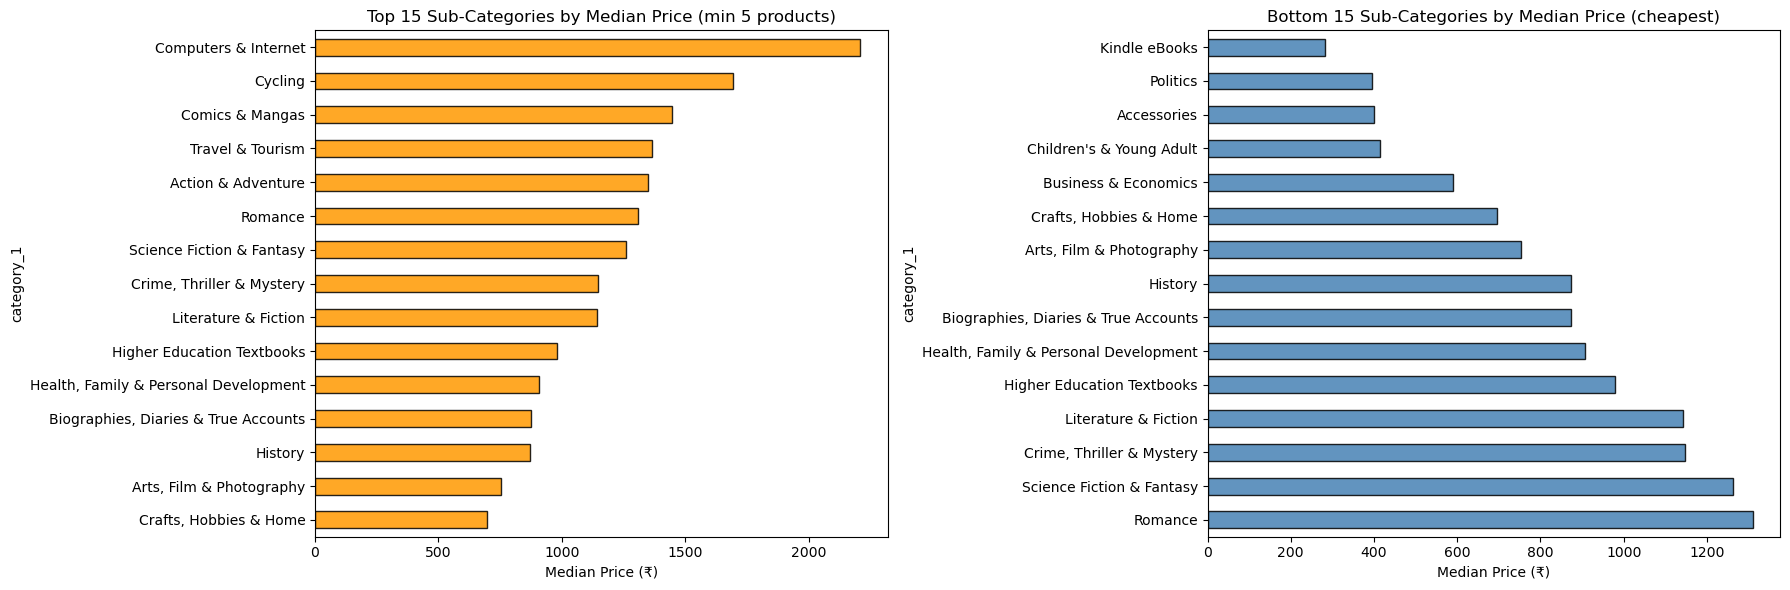

In [17]:
# --- Cálculo de las 15 Subcategorías Más Caras ---
# 1. Agrupamos los datos por la columna 'category_1' (Subcategorías).
# 2. Calculamos la mediana de precio ('median') y contamos cuántos productos tiene cada una ('count').
# 3. '.query('count >= 5')' es un filtro: solo nos interesan subcategorías que tengan 5 o más productos (para evitar que un solo producto muy caro altere el análisis).
# 4. Ordenamos de mayor a menor según su mediana de precio y nos quedamos con el Top 15 (.head(15)).
top_cat1_price = (df_priced.groupby('category_1')['price_clean']
                  .agg(['median','count'])
                  .query('count >= 5')
                  .sort_values('median', ascending=False)
                  .head(15))

# --- Configuración de los Gráficos ---
# Creamos una figura con 1 fila y 2 columnas para mostrar los dos gráficos lado a lado.
# El tamaño de la figura completa es de 18 de ancho por 6 de alto.
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Gráfico 1: Las 15 Subcategorías con Precios Más Altos ---
# Tomamos el Top 15 de las más caras, las ordenamos de menor a mayor (para que al graficar en horizontal la más cara quede arriba).
# Creamos un gráfico de barras horizontales (.plot.barh) ubicado en la primera posición (izquierda: ax=axes[0]).
# Usamos el color naranja de Amazon con bordes negros y un 85% de opacidad.
top_cat1_price['median'].sort_values().plot.barh(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)

# Agregamos el título descriptivo y la etiqueta del eje X (Precio Mediano en Rupias) al primer gráfico.
axes[0].set_title('Top 15 Sub-Categories by Median Price (min 5 products)')
axes[0].set_xlabel('Median Price (₹)')


# --- Cálculo de las 15 Subcategorías Más Baratas (Económicas) ---
# Hacemos exactamente el mismo proceso: agrupamos, calculamos mediana y cantidad, y filtramos que tengan mínimo 5 productos.
# La diferencia es que aquí ordenamos de menor a mayor (.sort_values('median')) para encontrar las 15 más baratas (.head(15)).
bottom_cat1 = (df_priced.groupby('category_1')['price_clean']
               .agg(['median','count'])
               .query('count >= 5')
               .sort_values('median')
               .head(15))

# --- Gráfico 2: Las 15 Subcategorías Más Baratas ---
# Tomamos el grupo de las más baratas, las ordenamos de mayor a menor y creamos el gráfico horizontal en la segunda posición (derecha: ax=axes[1]).
# Para diferenciarlo visualmente del gráfico de productos caros, usamos un color azul acero ('steelblue').
bottom_cat1['median'].sort_values(ascending=False).plot.barh(
    ax=axes[1], color='steelblue', edgecolor='black', alpha=0.85)

# Agregamos el título descriptivo y la etiqueta del eje X al segundo gráfico.
axes[1].set_title('Bottom 15 Sub-Categories by Median Price (cheapest)')
axes[1].set_xlabel('Median Price (₹)')


# --- Ajustes Finales ---
# Ajusta de forma automática los espacios entre los dos gráficos para evitar que los textos de los ejes se encimen.
plt.tight_layout()

# Muestra la figura con ambos gráficos en pantalla.
plt.show()

## 7.Análisis de Disponibilidad

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color:#0066cc;">
<b>
Este análisis sirve para entender cómo se distribuye el inventario de los productos y
si el hecho de que un artículo esté agotado o disponible tiene alguna relación con su costo. Al cruzar los precios con el estado del stock,
podemos descubrir de forma sencilla si los productos más caros o exclusivos tienden a acabarse más rápido que los normales. Técnicamente, este 
bloque nos permite evaluar una variable categórica discreta mediante proporciones (porcentajes) y formas visuales, ayudándonos a comprobar si existe
patrones importantes en el comportamiento de la tienda antes de pasar a la etapa de predicción con los modelos.<b>
<div>

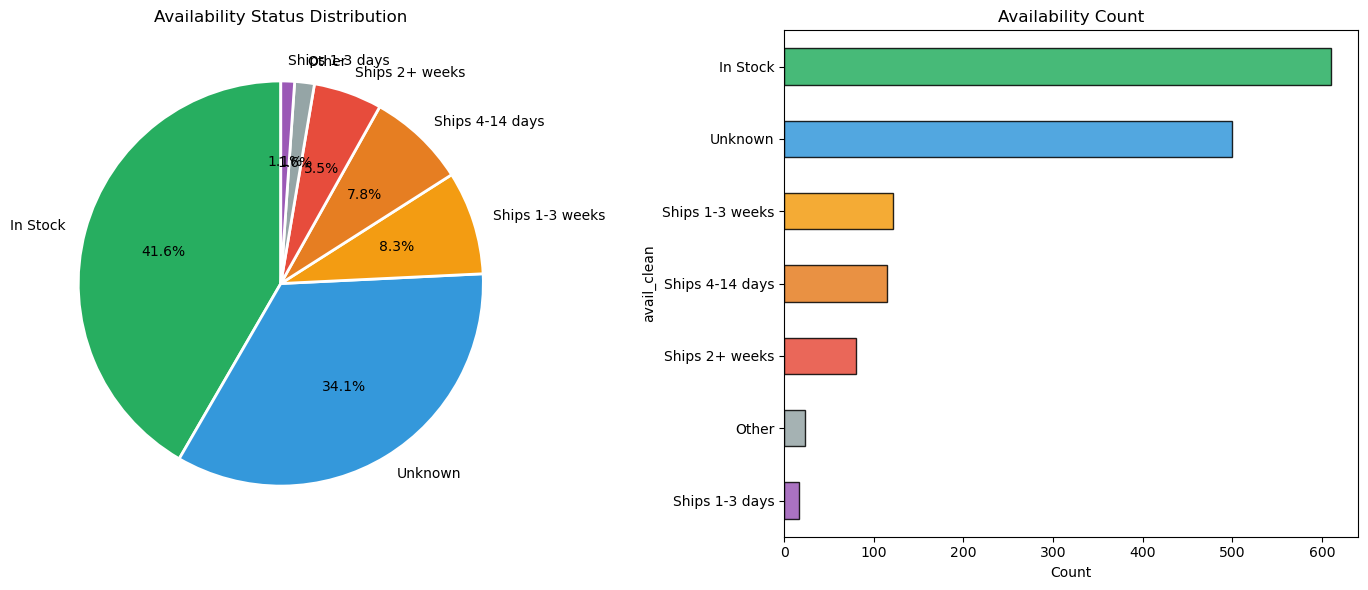

In [20]:
# ============================================================
# SECTION 6 — Availability Analysis
# ============================================================
avail_counts = df['avail_clean'].value_counts()
avail_colors = ['#27ae60','#3498db','#f39c12','#e67e22','#e74c3c','#95a5a6','#9b59b6','#1abc9c']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(avail_counts.values, labels=avail_counts.index,
            colors=avail_colors[:len(avail_counts)],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Availability Status Distribution')

avail_counts.sort_values().plot.barh(
    ax=axes[1], color=avail_colors[:len(avail_counts)][::-1],
    edgecolor='black', alpha=0.85)
axes[1].set_title('Availability Count')
axes[1].set_xlabel('Count')

plt.tight_layout(); plt.show()

C:\Users\PC-25\AppData\Local\Temp\ipykernel_6836\1063884491.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(avail_groups, labels=avail_price.index, patch_artist=True,


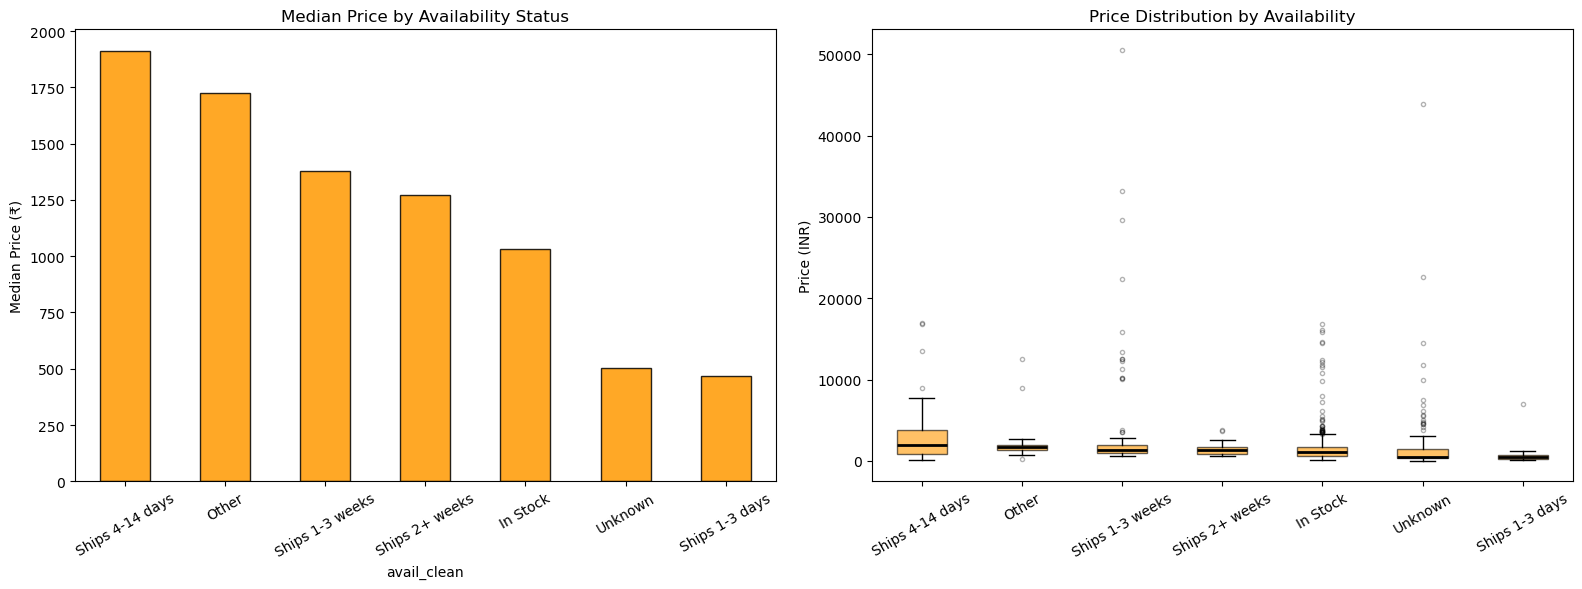

Price by availability:
                 median    mean  count
avail_clean                           
Ships 4-14 days  1912.3  2874.6    115
Other            1724.2  2459.4     20
Ships 1-3 weeks  1377.0  3231.6    121
Ships 2+ weeks   1273.0  1385.9     80
In Stock         1030.5  1488.7    602
Unknown           502.0  1881.5    134
Ships 1-3 days    469.0   874.9     16


In [21]:
# Price by availability status
avail_price = df_priced.groupby('avail_clean')['price_clean'].agg(['median','mean','count']).round(1)
avail_price = avail_price[avail_price['count'] >= 5].sort_values('median', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

avail_price['median'].plot.bar(ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Median Price by Availability Status')
axes[0].set_ylabel('Median Price (₹)'); axes[0].tick_params(axis='x', rotation=30)

avail_groups = [df_priced[df_priced['avail_clean']==a]['price_clean'].dropna()
                for a in avail_price.index]
bp = axes[1].boxplot(avail_groups, labels=avail_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))
for patch in bp['boxes']:
    patch.set_facecolor('#FF9900'); patch.set_alpha(0.6)
axes[1].set_title('Price Distribution by Availability')
axes[1].set_ylabel('Price (INR)'); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()
print('Price by availability:')
print(avail_price.to_string())

C:\Users\PC-25\AppData\Local\Temp\ipykernel_6836\1063884491.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(avail_groups, labels=avail_price.index, patch_artist=True,


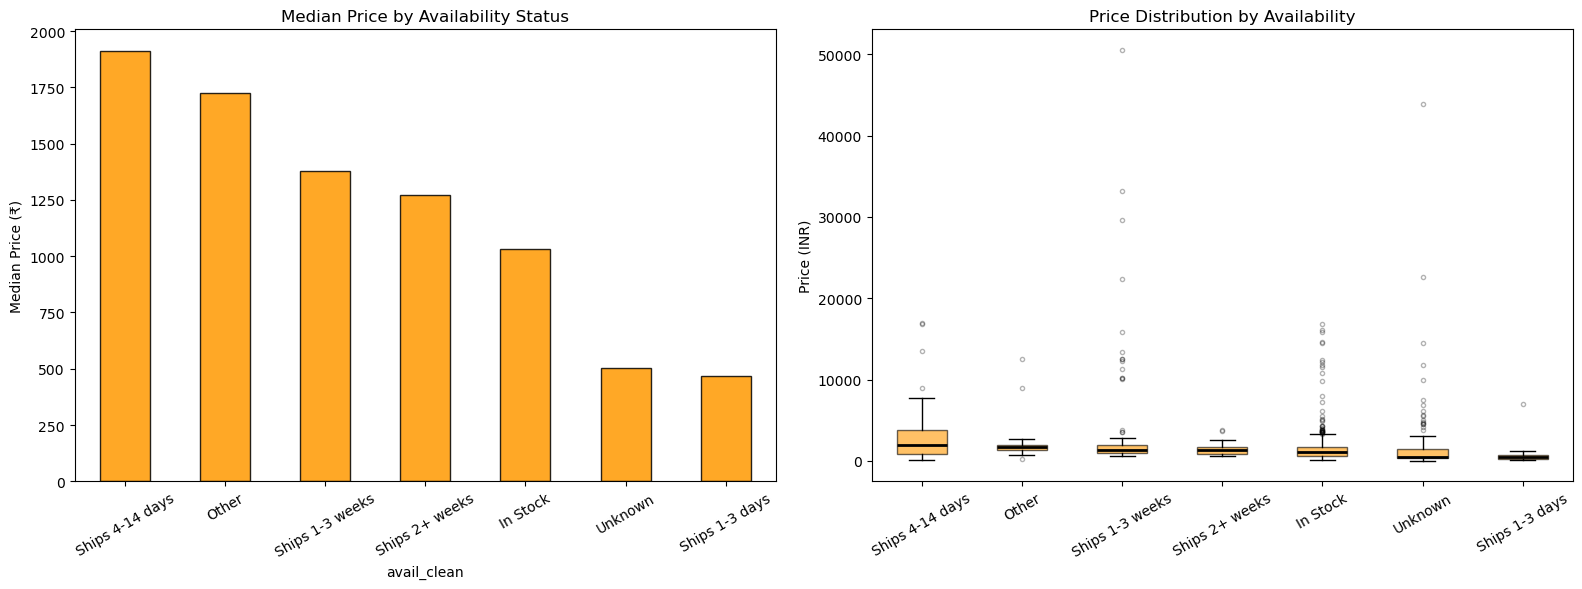

Price by availability:
                 median    mean  count
avail_clean                           
Ships 4-14 days  1912.3  2874.6    115
Other            1724.2  2459.4     20
Ships 1-3 weeks  1377.0  3231.6    121
Ships 2+ weeks   1273.0  1385.9     80
In Stock         1030.5  1488.7    602
Unknown           502.0  1881.5    134
Ships 1-3 days    469.0   874.9     16


In [21]:
# Price by availability status
avail_price = df_priced.groupby('avail_clean')['price_clean'].agg(['median','mean','count']).round(1)
avail_price = avail_price[avail_price['count'] >= 5].sort_values('median', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

avail_price['median'].plot.bar(ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Median Price by Availability Status')
axes[0].set_ylabel('Median Price (₹)'); axes[0].tick_params(axis='x', rotation=30)

avail_groups = [df_priced[df_priced['avail_clean']==a]['price_clean'].dropna()
                for a in avail_price.index]
bp = axes[1].boxplot(avail_groups, labels=avail_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))
for patch in bp['boxes']:
    patch.set_facecolor('#FF9900'); patch.set_alpha(0.6)
axes[1].set_title('Price Distribution by Availability')
axes[1].set_ylabel('Price (INR)'); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()
print('Price by availability:')
print(avail_price.to_string())

C:\Users\PC-25\AppData\Local\Temp\ipykernel_6836\1063884491.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(avail_groups, labels=avail_price.index, patch_artist=True,


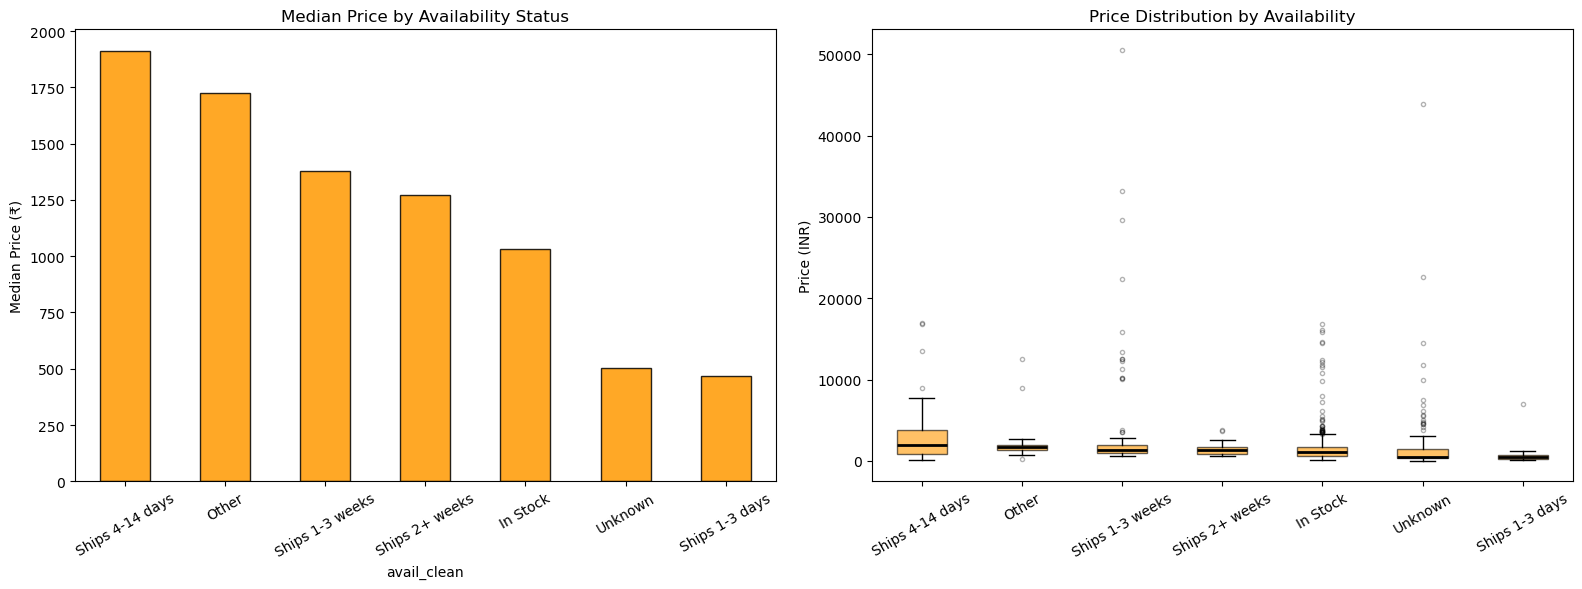

Price by availability:
                 median    mean  count
avail_clean                           
Ships 4-14 days  1912.3  2874.6    115
Other            1724.2  2459.4     20
Ships 1-3 weeks  1377.0  3231.6    121
Ships 2+ weeks   1273.0  1385.9     80
In Stock         1030.5  1488.7    602
Unknown           502.0  1881.5    134
Ships 1-3 days    469.0   874.9     16


In [21]:
# Price by availability status
avail_price = df_priced.groupby('avail_clean')['price_clean'].agg(['median','mean','count']).round(1)
avail_price = avail_price[avail_price['count'] >= 5].sort_values('median', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

avail_price['median'].plot.bar(ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Median Price by Availability Status')
axes[0].set_ylabel('Median Price (₹)'); axes[0].tick_params(axis='x', rotation=30)

avail_groups = [df_priced[df_priced['avail_clean']==a]['price_clean'].dropna()
                for a in avail_price.index]
bp = axes[1].boxplot(avail_groups, labels=avail_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))
for patch in bp['boxes']:
    patch.set_facecolor('#FF9900'); patch.set_alpha(0.6)
axes[1].set_title('Price Distribution by Availability')
axes[1].set_ylabel('Price (INR)'); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()
print('Price by availability:')
print(avail_price.to_string())

## 8.ANÁLISIS DE CORRELACIÓN

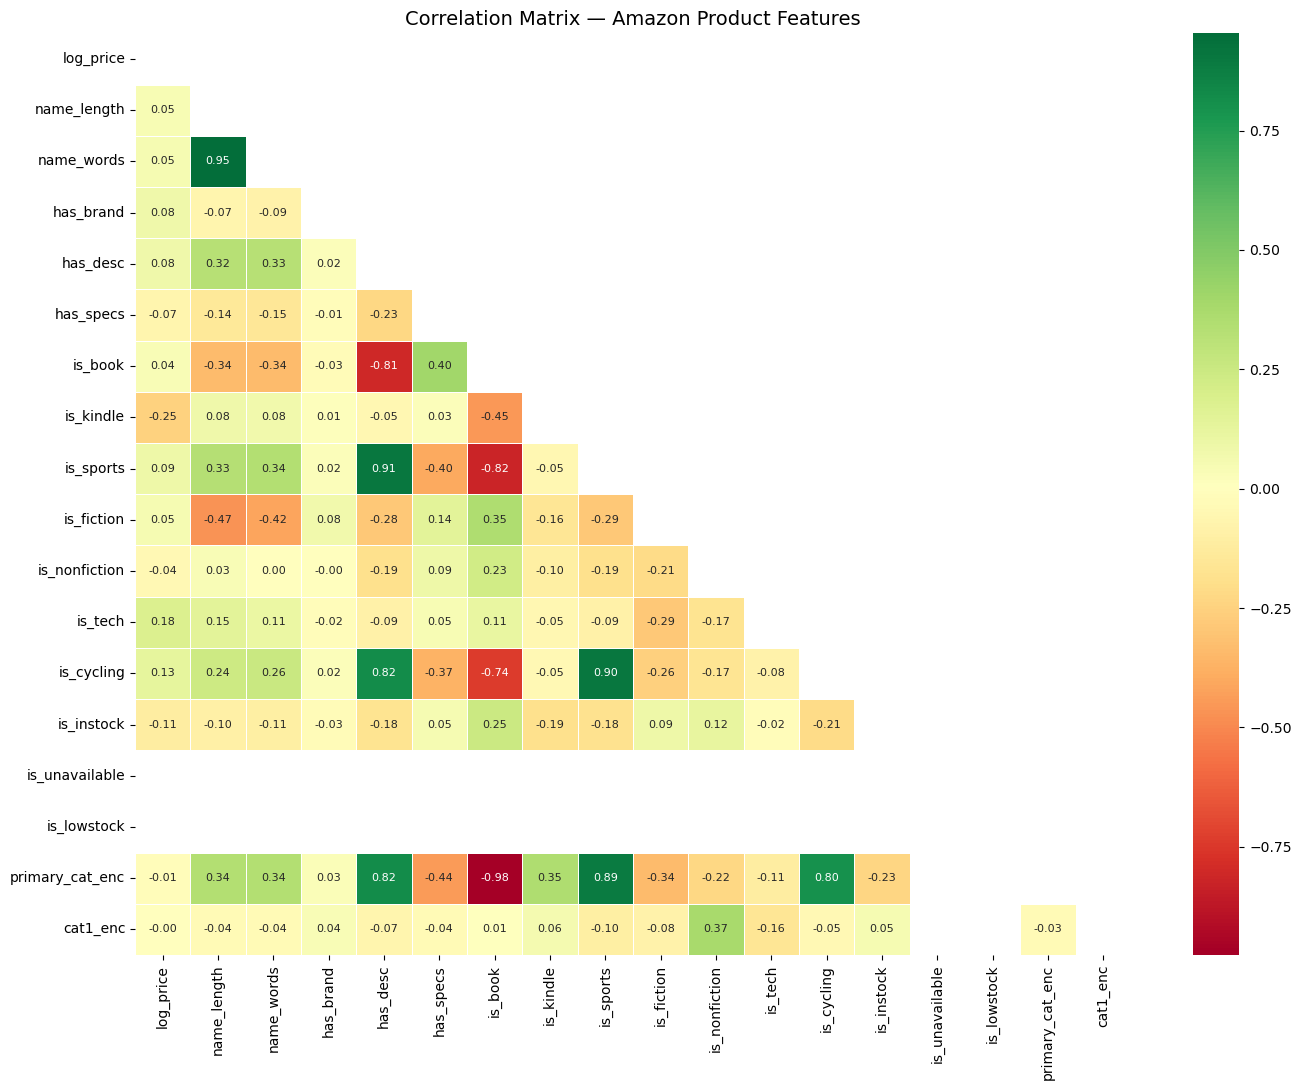

Top correlations with log_price:
is_tech            0.177085
is_cycling         0.127066
is_sports          0.092209
has_brand          0.083667
has_desc           0.081207
is_fiction         0.054054
name_words         0.052497
name_length        0.046656
is_book            0.037972
cat1_enc          -0.000082
primary_cat_enc   -0.013181
is_nonfiction     -0.043602
has_specs         -0.067499
is_instock        -0.112979
is_kindle         -0.246389
is_unavailable          NaN
is_lowstock             NaN


In [22]:
# ============================================================
# SECTION 7 — Correlation Analysis
# ============================================================
corr_cols = ['log_price','name_length','name_words','has_brand','has_desc',
             'has_specs','is_book','is_kindle','is_sports','is_fiction',
             'is_nonfiction','is_tech','is_cycling','is_instock',
             'is_unavailable','is_lowstock','primary_cat_enc','cat1_enc']

corr = df_priced[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, annot_kws={'size': 8})
plt.title('Correlation Matrix — Amazon Product Features', fontsize=14)
plt.tight_layout(); plt.show()

print('Top correlations with log_price:')
print(corr['log_price'].drop('log_price').sort_values(ascending=False).to_string())

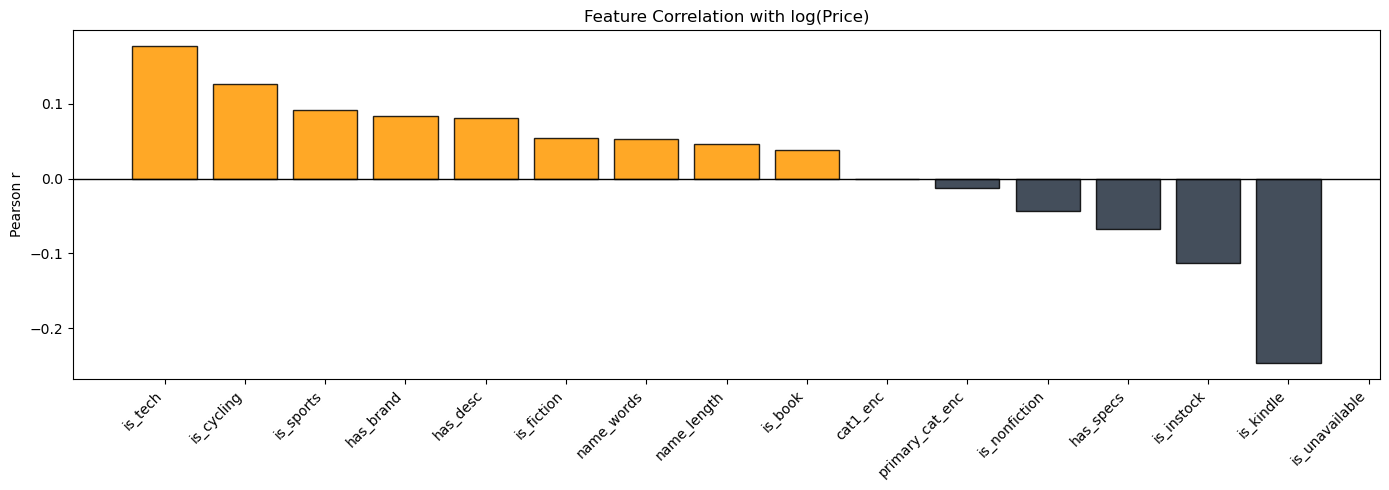

In [23]:
# Feature correlation bar chart
feat_corr = corr['log_price'].drop('log_price').sort_values(ascending=False)

plt.figure(figsize=(14, 5))
colors_fc = ['#FF9900' if v > 0 else '#232F3E' for v in feat_corr.values]
plt.bar(feat_corr.index, feat_corr.values, color=colors_fc, edgecolor='black', alpha=0.85)
plt.axhline(0, color='black', lw=1)
plt.title('Feature Correlation with log(Price)')
plt.ylabel('Pearson r'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

C:\Users\PC-25\AppData\Local\Temp\ipykernel_6836\2946963551.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),


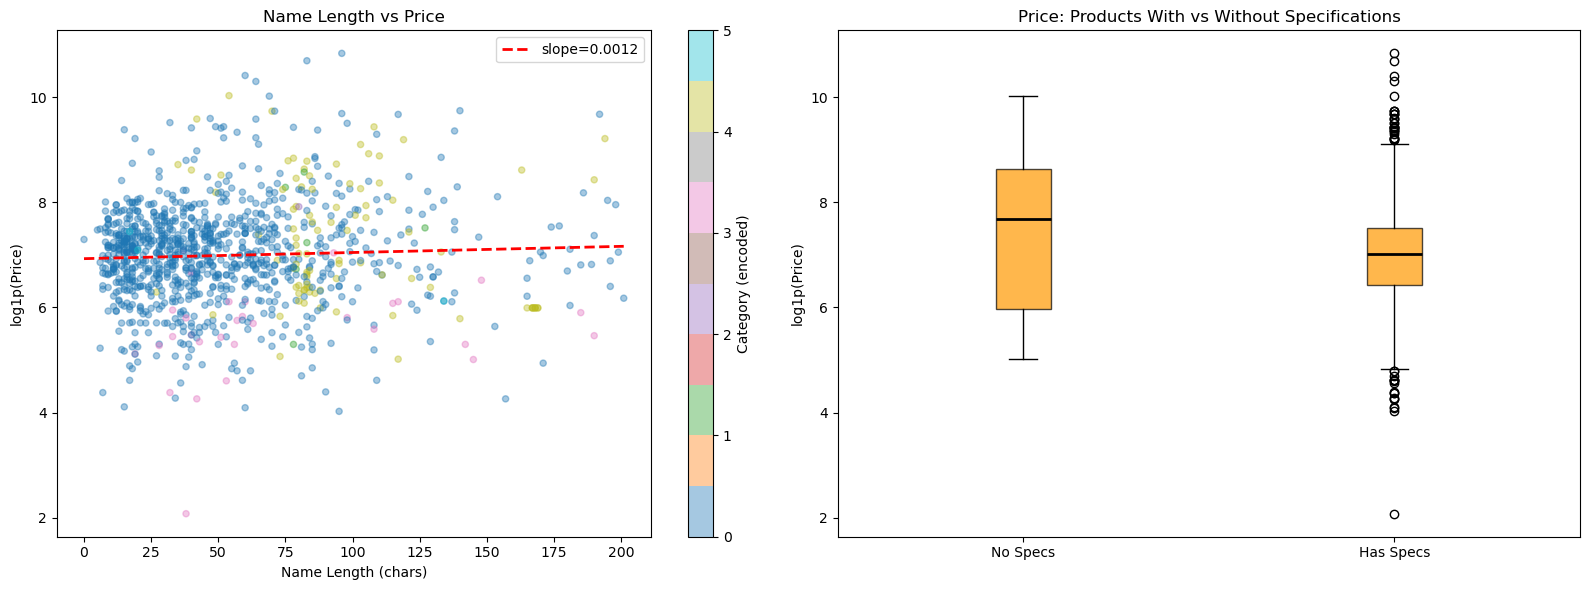

In [24]:
# Scatter: name length vs price
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(df_priced['name_length'], df_priced['log_price'],
                     c=df_priced['primary_cat_enc'], cmap='tab10',
                     alpha=0.4, s=20)
plt.colorbar(sc, ax=axes[0], label='Category (encoded)')
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[0].plot(x, m*x+b, 'r--', lw=2, label=f'slope={m:.4f}')
axes[0].set_xlabel('Name Length (chars)'); axes[0].set_ylabel('log1p(Price)')
axes[0].set_title('Name Length vs Price'); axes[0].legend()

# Price by has_specs
axes[1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
                 np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
                labels=['No Specs','Has Specs'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_title('Price: Products With vs Without Specifications')
axes[1].set_ylabel('log1p(Price)')

plt.tight_layout(); plt.show()